<a href="https://colab.research.google.com/github/wisnalaa/Numerik/blob/main/Prak9_Numerik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
def lagrange_interpolate(x_data, y_data, x):
    """
    Menghitung nilai interpolasi di titik x
    menggunakan polinom Lagrange.
    x_data, y_data: list/tuple data (x_i, y_i)
    x: titik yang akan diinterpolasi
    """
    n = len(x_data)
    total = 0.0

    for i in range(n):
        # Bangun basis L_i(x)
        term = y_data[i]
        for j in range(n):
            if j != i:
                term *= (x - x_data[j]) / (x_data[i] - x_data[j])
        total += term

    return total


def main():
    # Dataset kecil
    x_data = [0, 1, 2, 3]
    y_data = [1, 4, 9, 16]

    x_ujian = 1.5
    y_interp = lagrange_interpolate(x_data, y_data, x_ujian)

    print(f"x = {x_ujian}")
    print(f"y interpolasi (Lagrange) = {y_interp}")


if __name__ == "__main__":
    main()

x = 1.5
y interpolasi (Lagrange) = 6.25


In [6]:
def newton_divided_diff(x_data, y_data):
    """
    Menghitung koefisien polinom Newton
    menggunakan tabel selisih terbagi.
    Menghasilkan list 'coef' dengan coef[k] = a_k.
    """
    n = len(x_data)
    coef = y_data.copy()  # mulai dari f[x_i]

    # Bangun divided differences in-place
    for j in range(1, n):
        for i in range(n - 1, j - 1, -1):
            coef[i] = (coef[i] - coef[i - 1]) / (x_data[i] - x_data[i - j])

    return coef


def newton_evaluate(x_data, coef, x):
    """
    Evaluasi polinom Newton di titik x
    menggunakan koefisien 'coef' dan data x_data.
    """
    n = len(coef)
    result = coef[n - 1]

    # Bentuk Horner terbalik
    for k in range(n - 2, -1, -1):
        result = result * (x - x_data[k]) + coef[k]

    return result


def main():
    # Dataset besar (21 titik)
    x_data = list(range(0, 21))  # [0, 1, ..., 20]
    y_data = [(x + 1) ** 2 for x in x_data]

    # Hitung koefisien Newton
    coef = newton_divided_diff(x_data, y_data)

    # Beberapa titik uji
    x_uji_list = [2.5, 7.5, 12.3, 19.7]

    for x in x_uji_list:
        y_interp = newton_evaluate(x_data, coef, x)
        y_asli = (x + 1) ** 2  # fungsi asli
        print(f"x = {x}")
        print(f"  y interpolasi  = {y_interp}")
        print(f"  y fungsi asli  = {y_asli}")
        print(f"  error absolut  = {abs(y_interp - y_asli)}")
        print("-" * 40)


if __name__ == "__main__":
    main()

x = 2.5
  y interpolasi  = 12.25
  y fungsi asli  = 12.25
  error absolut  = 0.0
----------------------------------------
x = 7.5
  y interpolasi  = 72.25
  y fungsi asli  = 72.25
  error absolut  = 0.0
----------------------------------------
x = 12.3
  y interpolasi  = 176.89000000000001
  y fungsi asli  = 176.89000000000001
  error absolut  = 0.0
----------------------------------------
x = 19.7
  y interpolasi  = 428.48999999999995
  y fungsi asli  = 428.48999999999995
  error absolut  = 0.0
----------------------------------------


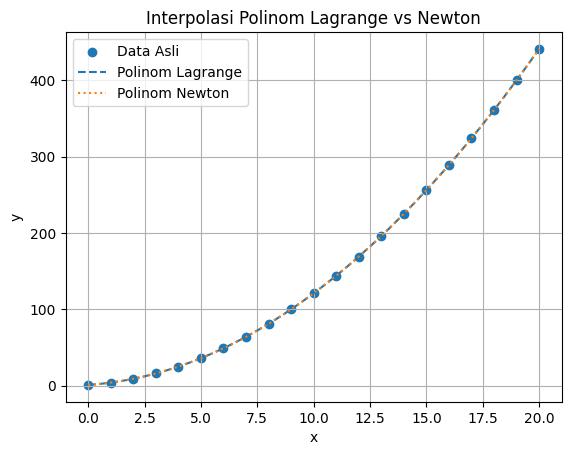

In [8]:
import matplotlib.pyplot as plt

def main():
    x_data = list(range(0, 21))
    y_data = [(x + 1) ** 2 for x in x_data]

    # Siapkan titik untuk digambar
    x_plot = [i / 2 for i in range(0, 41)]  # 0, 0.5, ..., 20
    y_lagrange = [lagrange_interpolate(x_data, y_data, x) for x in x_plot]

    coef = newton_divided_diff(x_data, y_data)
    y_newton = [newton_evaluate(x_data, coef, x) for x in x_plot]

    # Plot
    plt.figure()
    plt.scatter(x_data, y_data, label="Data Asli")
    plt.plot(x_plot, y_lagrange, linestyle="--", label="Polinom Lagrange")
    plt.plot(x_plot, y_newton, linestyle=":", label="Polinom Newton")
    plt.legend()
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Interpolasi Polinom Lagrange vs Newton")
    plt.grid(True)
    plt.show()


if __name__ == "__main__":
    main()